# Foot Support Footprint and Pseudo-Footbed Playground

This notebook implements the first three geometry pieces from Section 1.3 of the foot-fitting notes:

1. Extract lower sole/support geometry from each canonical shoe mesh.
2. Project that support geometry into the `X-Z` footprint plane and estimate centerline, width profile, heel/ball/toe regions.
3. Build a simple constant-offset pseudo-footbed profile that can later replace the current bbox-based vertical and lateral anchors.

The implementation lives in `FootShellGaussian/foot_prior/support_footprint.py`; this notebook is for visual inspection and measurement, not one-off notebook-only logic.

## Section 1.3 Formulae Implemented

Support faces are selected with the same idea as the report:

$$\mathcal{F}_{\mathrm{sole}} = \{ f : d_b(c_f) \ge q_{\tau}(d_b),\; n_f \cdot \hat{y}_S \ge \cos \theta_{\mathrm{sole}} \}.$$

Then the footprint centerline is computed slice-by-slice:

$$m(x)=\frac{1}{2}\left(z_L(x)+z_R(x)\right).$$

For production fitting, this support centerline should replace the current bbox lateral anchor. The pseudo-footbed is initially simple:

$$B(x,z) \approx B_{\mathrm{outer}}(x,z) + \mathrm{up\_sign}\cdot T_{\mathrm{bottom}}.$$

In our current convention `up_sign=-1`, so moving from outsole toward the footbed decreases `Y`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

PROJECT_ROOT = Path('/data/abelde/projects/active/Shell_Gaussian')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from FootShellGaussian.foot_prior import load_triangle_mesh, mesh_bounds
from FootShellGaussian.foot_prior.support_footprint import (
    SupportFootprintConfig,
    extract_support_footprint,
    save_support_footprint_artifacts,
)

GSHELL_OUTPUT_ROOT = PROJECT_ROOT / 'baselines/GShell/output/turntable-512-768'
ANALYSIS_ROOT = PROJECT_ROOT / 'baselines/GShell/output/support_footbed_analysis'
ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

print('GShell output root:', GSHELL_OUTPUT_ROOT)
print('Analysis output root:', ANALYSIS_ROOT)

GShell output root: /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/turntable-512-768
Analysis output root: /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis


## Configuration

The default extractor uses a broad lower-sole band (`bottom_quantile=0.80`). A very strict value such as `0.96` or `0.98` often selects only the ground-contact patch, which can miss raised toe/heel geometry. The quantile remains configurable so we can compare strict contact vs broader usable sole footprint.

In [2]:
CONFIG = SupportFootprintConfig(
    shoe_length_axis=0,
    shoe_up_axis=1,
    shoe_width_axis=2,
    shoe_up_sign=-1.0,
    bottom_quantile=0.80,
    fallback_bottom_quantile=0.70,
    normal_angle_degrees=65.0,
    grid_resolution=192,
    footbed_offset=0.015,
)

SHOES = [
    'Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable',
    'Air-Jordan-1-Retro-High-Og-Washed-Black-Gs_turntable',
    'Air-Jordan-1-Retro-High-Og-White-Cement-Gs_turntable',
    'Crocs-Classic-Clog-Cinnamon-Toast-Crunch-Gs_turntable',
    'Ugg-Classic-Short-Ii-Boot-Rock-Rose-Toddler_turntable',
    'Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant_turntable',
    'Nike-Calm-Slide-Cinnamon-Monarch_turntable',
]

pprint(CONFIG)

SupportFootprintConfig(shoe_length_axis=0,
                       shoe_up_axis=1,
                       shoe_width_axis=2,
                       shoe_up_sign=-1.0,
                       bottom_quantile=0.8,
                       fallback_bottom_quantile=0.7,
                       normal_angle_degrees=65.0,
                       fallback_normal_angle_degrees=88.0,
                       min_support_faces=40,
                       grid_resolution=192,
                       grid_padding_fraction=0.03,
                       morphology_iterations=3,
                       component_keep_ratio=0.04,
                       min_component_pixels=8,
                       min_slice_pixels=3,
                       centerline_smooth_window=9,
                       support_axis_quantile=0.9,
                       footbed_offset=0.015,
                       use_open_boundary=True,
                       open_bottom_quantile=0.58,
                       broad_support_quantile=0.55,
     

## Reusable Runner

For each shoe, the runner loads both `mesh_watertight/mesh.obj` and `mesh/mesh.obj`. The open mesh provides the trusted lower cut boundary; the watertight mesh provides the surface data. The extractor writes the JSON summary and visualization artifacts, then returns a compact row of measurements.

In [3]:
def mesh_path_for_scene(scene_name: str, prefer: str = 'mesh_watertight') -> Path:
    scene_dir = GSHELL_OUTPUT_ROOT / scene_name
    candidates = [
        scene_dir / prefer / 'mesh.obj',
        scene_dir / 'mesh_watertight' / 'mesh.obj',
        scene_dir / 'mesh' / 'mesh.obj',
        scene_dir / 'pass1' / 'mesh.obj',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'No mesh.obj found for {scene_name}')


def open_mesh_path_for_scene(scene_name: str) -> Path:
    return mesh_path_for_scene(scene_name, prefer='mesh')


def run_support_analysis(scene_name: str, config: SupportFootprintConfig = CONFIG) -> dict:
    mesh_path = mesh_path_for_scene(scene_name, prefer='mesh_watertight')
    open_mesh_path = open_mesh_path_for_scene(scene_name)
    mesh = load_triangle_mesh(mesh_path)
    open_mesh = load_triangle_mesh(open_mesh_path)
    footprint = extract_support_footprint(mesh, config, open_mesh=open_mesh)
    scene_out = ANALYSIS_ROOT / scene_name
    artifacts = save_support_footprint_artifacts(mesh, footprint, scene_out)

    _, _, shoe_size, bbox_center = mesh_bounds(mesh.vertices)
    bbox_width_center = float(bbox_center[config.shoe_width_axis])
    support_width_anchor = float(footprint.suggested_width_anchor)
    lateral_delta = support_width_anchor - bbox_width_center

    row = {
        'scene': scene_name,
        'mesh_path': str(mesh_path),
        'open_mesh_path': str(open_mesh_path),
        'shoe_length': float(shoe_size[config.shoe_length_axis]),
        'shoe_width': float(shoe_size[config.shoe_width_axis]),
        'support_length': footprint.length_extent,
        'support_median_width': footprint.median_width,
        'bbox_width_center': bbox_width_center,
        'support_width_anchor': support_width_anchor,
        'support_minus_bbox_width': float(lateral_delta),
        'support_face_count': int(footprint.support_face_indices.size),
        'profile_point_count': int(footprint.centerline_x.size),
        'lower_boundary': None if footprint.lower_boundary is None else footprint.lower_boundary.to_summary_dict(),
        'artifacts': artifacts,
    }
    return row


def display_scene_artifacts(row: dict) -> None:
    print(row['scene'])
    print('support_minus_bbox_width:', row['support_minus_bbox_width'])
    for key in ['support_overlay', 'footprint', 'width_profile', 'footbed_profile']:
        print(key, row['artifacts'][key])
        display(Image(filename=row['artifacts'][key]))

## Run Batch Analysis

The key number for replacing bbox lateral centering is `support_minus_bbox_width`. If this is nonzero, the support-footprint centerline wants the foot shifted sideways relative to the old bbox center.

In [4]:
rows = []
for scene_name in SHOES:
    try:
        row = run_support_analysis(scene_name)
        rows.append(row)
        print(
            f"{scene_name:68s} "
            f"support_len={row['support_length']:.4f} "
            f"support_w={row['support_median_width']:.4f} "
            f"delta_z={row['support_minus_bbox_width']:+.5f}"
        )
    except Exception as exc:
        print(f'FAILED {scene_name}: {exc}')

summary_path = ANALYSIS_ROOT / 'support_footbed_summary.json'
with summary_path.open('w') as f:
    json.dump(rows, f, indent=2)
    f.write('\n')

print('Wrote:', summary_path)

Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable                      support_len=0.3199 support_w=0.0969 delta_z=-0.00289
Air-Jordan-1-Retro-High-Og-Washed-Black-Gs_turntable                 support_len=0.3071 support_w=0.0946 delta_z=-0.00177
Air-Jordan-1-Retro-High-Og-White-Cement-Gs_turntable                 support_len=0.2957 support_w=0.0922 delta_z=-0.00310
Crocs-Classic-Clog-Cinnamon-Toast-Crunch-Gs_turntable                support_len=0.2910 support_w=0.1058 delta_z=-0.00063
Ugg-Classic-Short-Ii-Boot-Rock-Rose-Toddler_turntable                support_len=0.2056 support_w=0.0867 delta_z=-0.00141
Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant_turntable               support_len=0.2217 support_w=0.0786 delta_z=+0.00057
Nike-Calm-Slide-Cinnamon-Monarch_turntable                           support_len=0.3921 support_w=0.1354 delta_z=+0.00092
Wrote: /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/support_footbed_summary.json


## Visual Inspection

Choose one `scene_index` and display the support-face overlay, footprint centerline, width profile, and pseudo-footbed profile.

Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable
support_minus_bbox_width: -0.002894193399697542
support_overlay /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable/support_faces_overlay.png


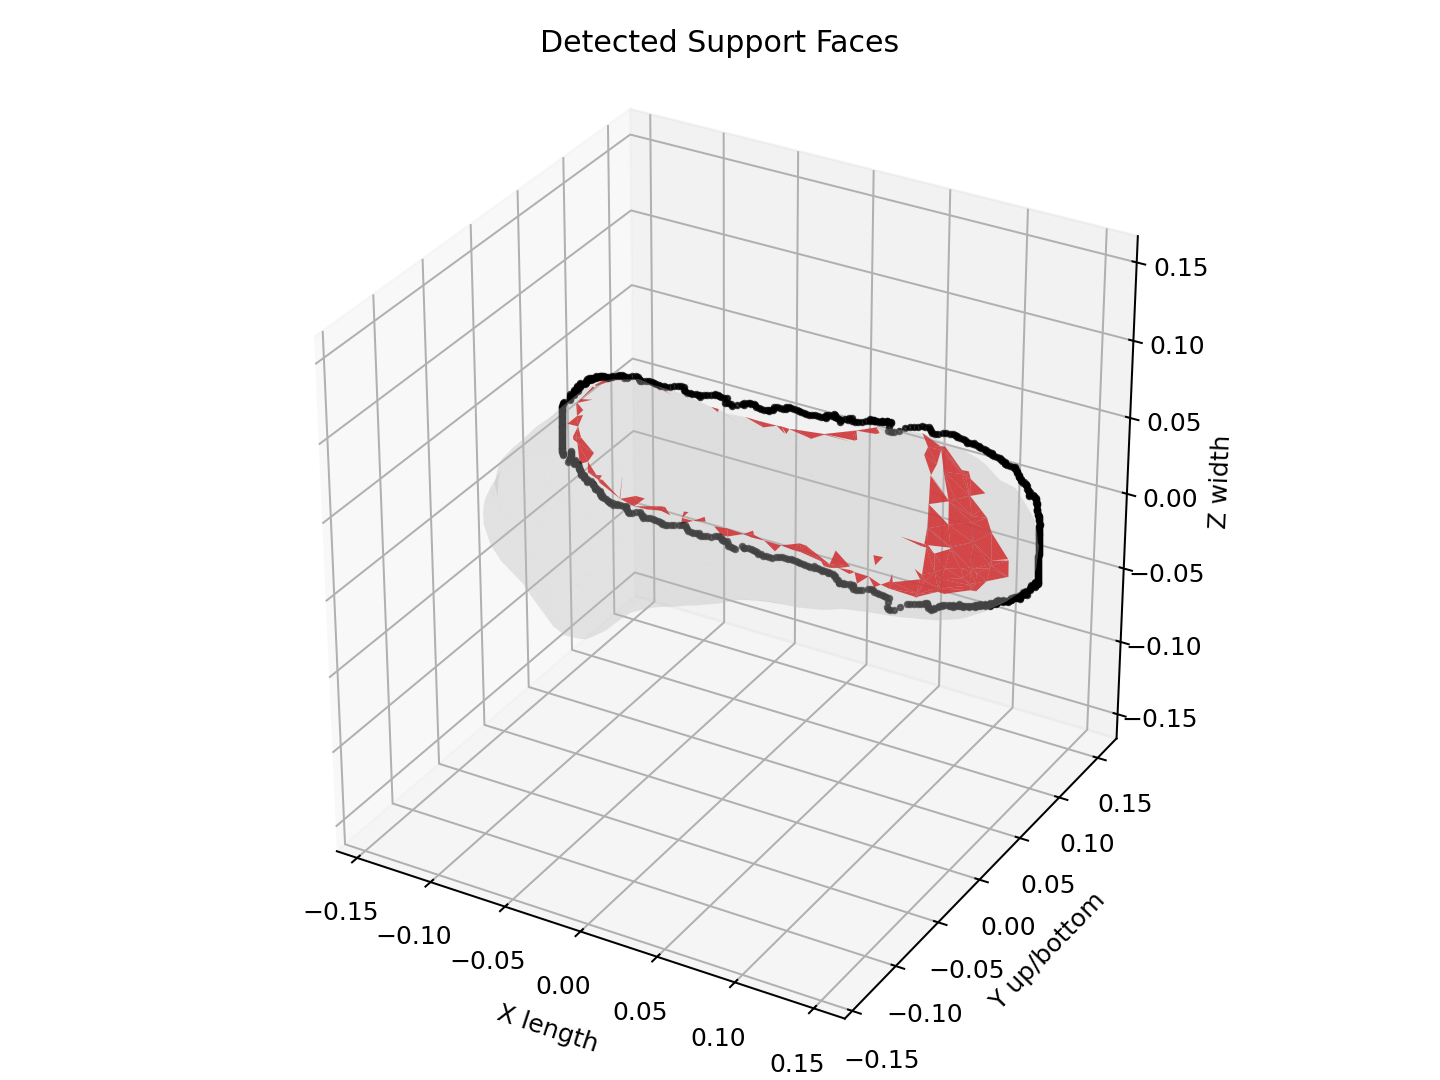

footprint /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable/footprint_centerline.png


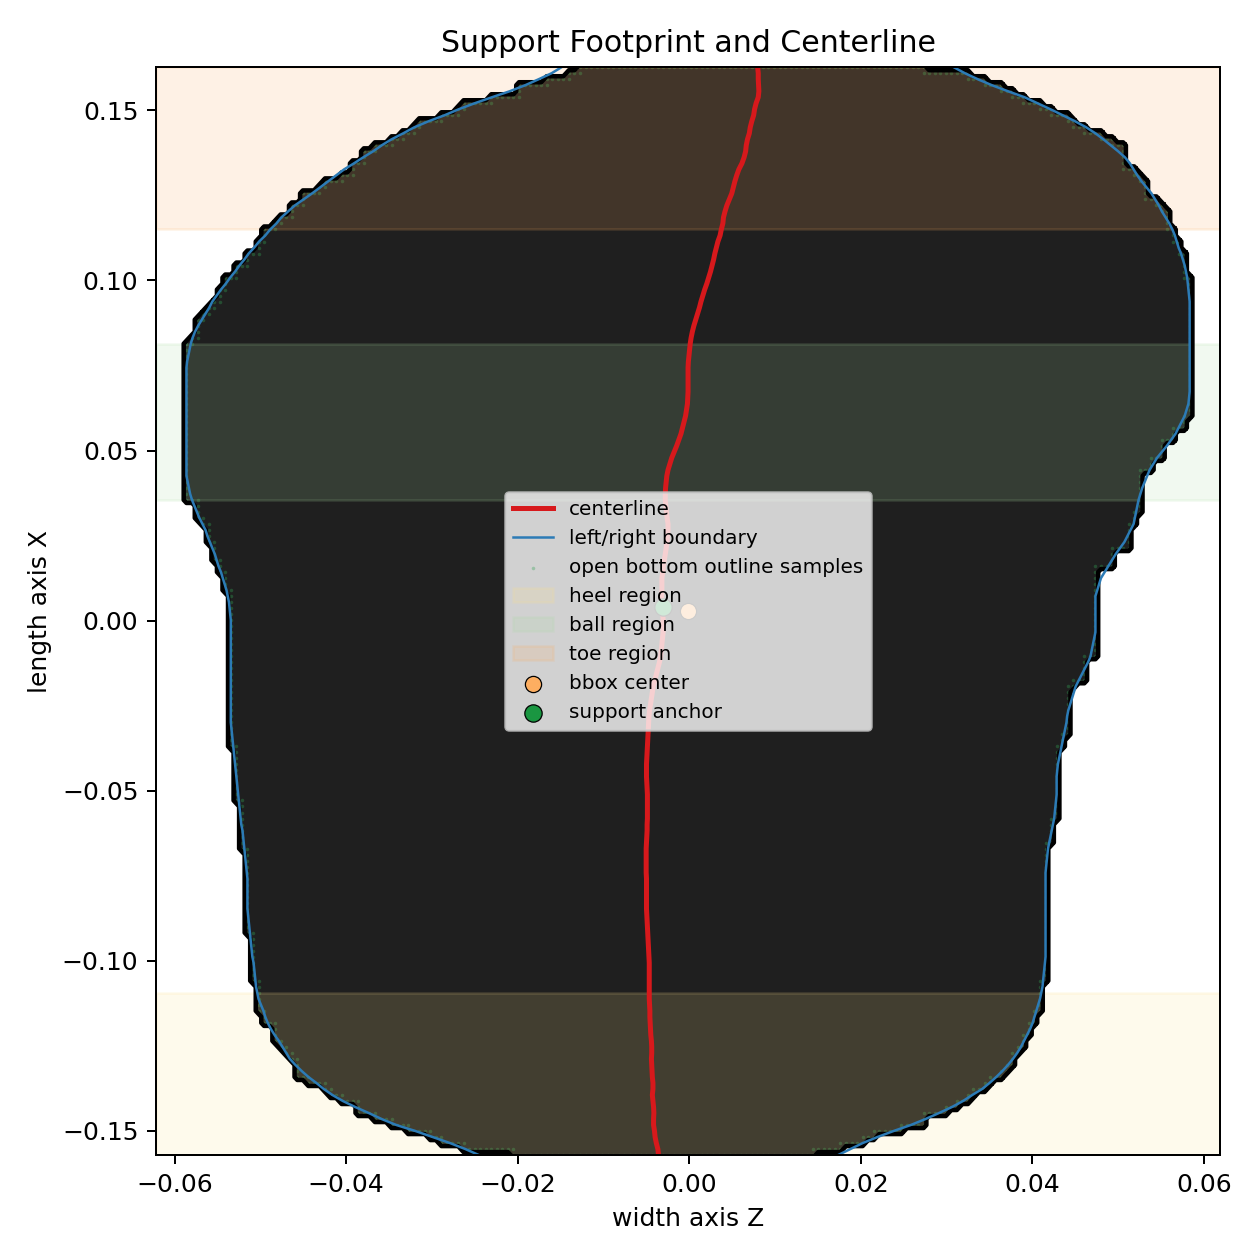

width_profile /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable/width_profile.png


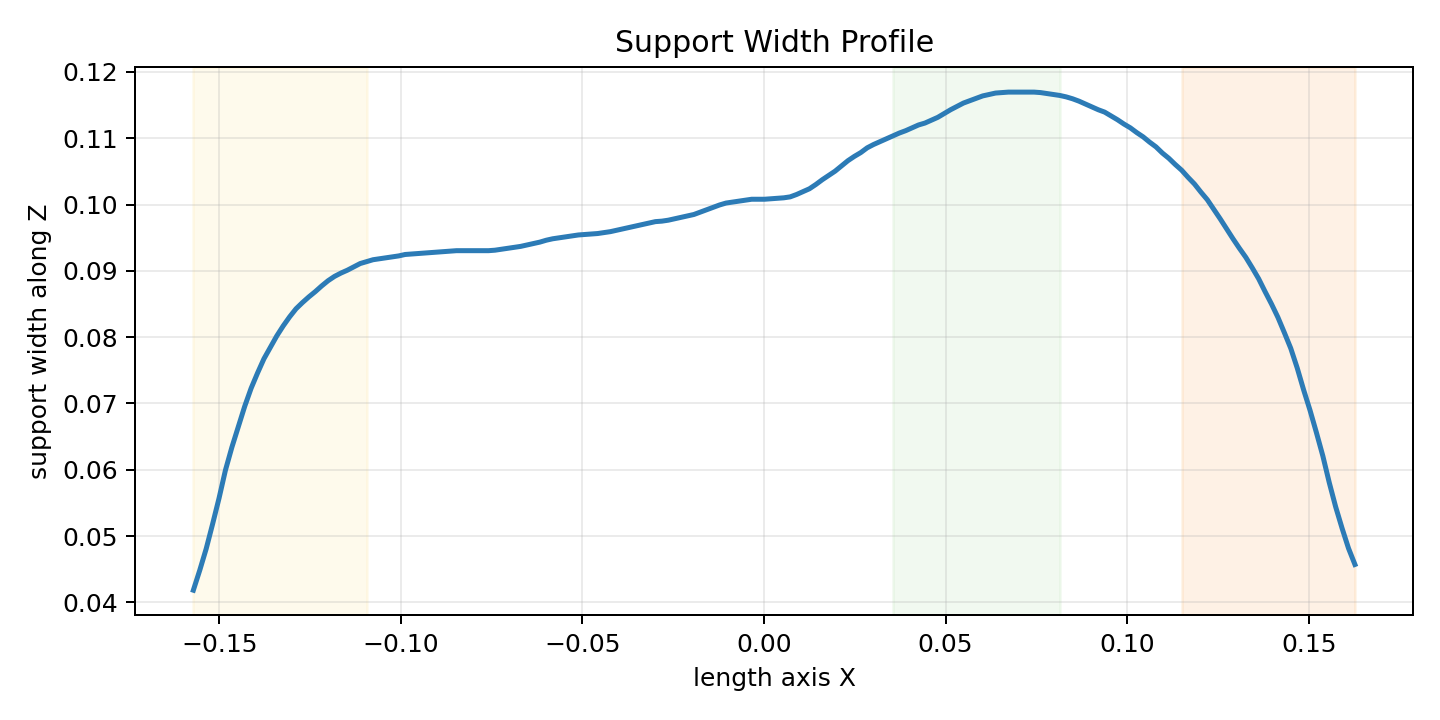

footbed_profile /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/support_footbed_analysis/Air-Jordan-1-Mid-Wear-Away-Chicago-Gs_turntable/footbed_profile.png


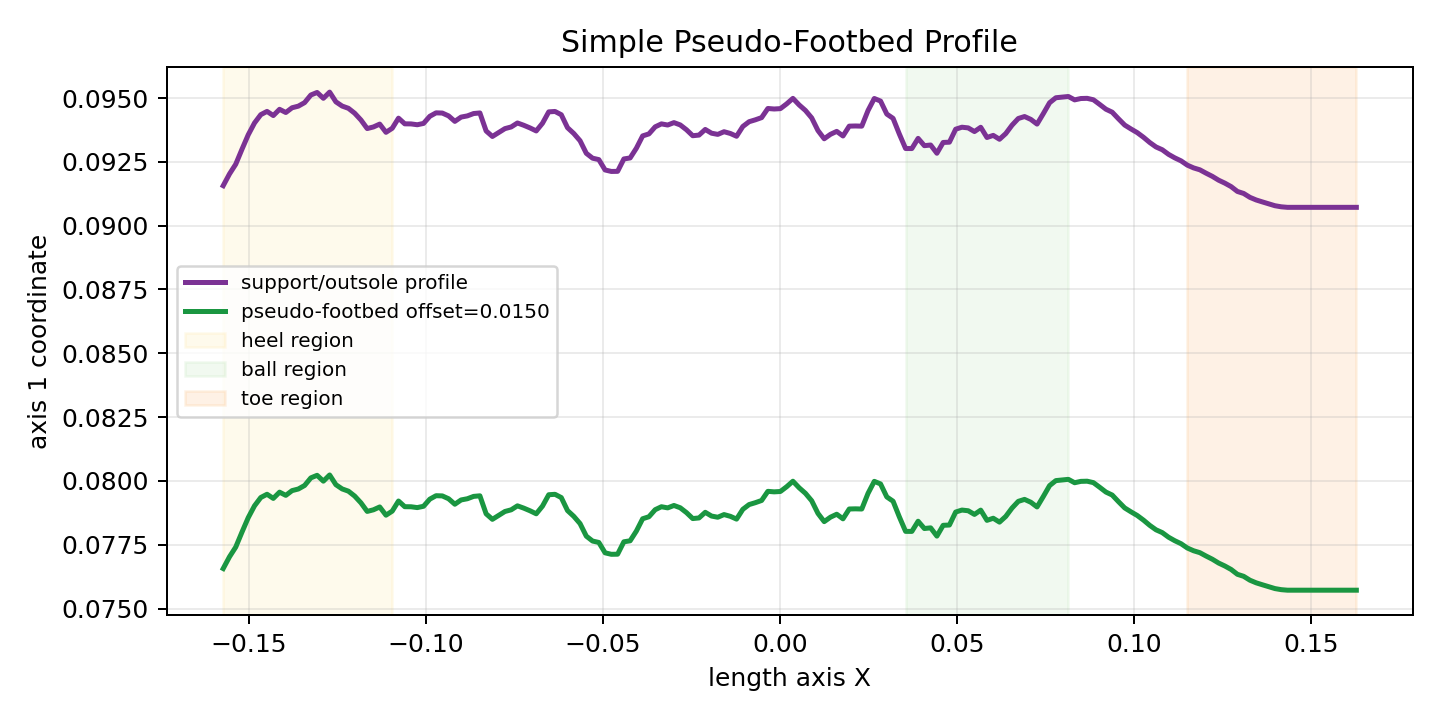

In [5]:
scene_index = 0
display_scene_artifacts(rows[scene_index])

## Strict Contact vs Broad Lower-Sole Band

Use this cell to compare the report's stricter contact-like rule against a broader lower-sole band. For final alignment, the broader lower-sole band is often more useful because it preserves heel/toe footprint information even when the shoe has toe spring or rocker geometry.

In [6]:
scene_name = SHOES[0]
mesh = load_triangle_mesh(mesh_path_for_scene(scene_name, prefer='mesh_watertight'))
open_mesh = load_triangle_mesh(open_mesh_path_for_scene(scene_name))

for q in [0.96, 0.90, 0.80, 0.70]:
    cfg = SupportFootprintConfig(
        bottom_quantile=q,
        fallback_bottom_quantile=max(0.50, q - 0.10),
        grid_resolution=192,
        footbed_offset=CONFIG.footbed_offset,
    )
    fp = extract_support_footprint(mesh, cfg, open_mesh=open_mesh)
    print(
        f'q={q:.2f}: faces={fp.support_face_indices.size:5d}, '
        f'length={fp.length_extent:.4f}, median_width={fp.median_width:.4f}, '
        f'fill={fp.confidence["footprint_fill_fraction"]:.3f}'
    )

q=0.96: faces= 1345, length=0.3199, median_width=0.0969, fill=0.737
q=0.90: faces= 1345, length=0.3199, median_width=0.0969, fill=0.737
q=0.80: faces=  240, length=0.3199, median_width=0.0969, fill=0.737
q=0.70: faces=  414, length=0.3199, median_width=0.0969, fill=0.737


## Next Integration Target

Once the footprint looks reliable across the problematic shoes, the next code change should happen in `build_alignment_from_meshes()`:

- keep the existing bbox path as fallback,
- compute `SupportFootprint` from the shoe mesh,
- replace `shoe_anchor[shoe_width_axis]` with `footprint.suggested_width_anchor`,
- replace or regularize yaw with the support centerline instead of whole-mesh PCA,
- replace the vertical `bottom_coordinate()` anchor with the pseudo-footbed profile near heel/ball regions.

That would move the pipeline from bbox alignment toward support/cavity-aware placement without jumping directly into the full Section 1.4 optimizer.

Honestly: we should stop trying to “get proper faces” directly.

That is the trap.

For 4000 shoes, selecting perfect red sole faces from messy watertight meshes will keep failing because:

```text
some soles have holes
some watertight meshes have fake bulges
some faces point sideways
some soles are curved
some meshes are low quality
some bottoms are broken into weird triangles
```

So the better idea is:

```text
Do not rely on perfect faces.
Build a clean floor surface from the mesh.
```

The black footprint gives us the 2D area:

```text
where the shoe bottom exists in X-Z
```

Then for each point inside that footprint, we estimate:

```text
what is the bottom/floor Y height here?
```

The best method is like this:

```text
1. Take the black footprint.
2. Put a grid over it.
3. For every grid cell inside the footprint:
   look at watertight mesh points/faces near that X-Z location.
4. Estimate the floor height using a robust value, not one triangle.
   Example: median or percentile of bottom-side Y values.
5. Smooth this into a clean floor curve/surface.
6. Use this clean floor for foot placement.
```

So instead of this:

```text
find perfect sole faces -> use them directly
```

we do this:

```text
black footprint + watertight samples -> clean floor height map
```

If we still want red faces for visualization, then after building the clean floor, we can select faces close to that floor. But those faces should be a debug view, not the main source of truth.

The more robust version is ray-based:

```text
For each X-Z grid point inside the footprint:
  shoot a vertical ray through the watertight mesh
  take the first intersection from the bottom side
  that gives the outsole/floor height
```

That is probably the cleanest next step.

So the next thing I would implement is:

```text
support_footprint.py
  add floor height map extraction
  add smoothed pseudo-footbed surface
  stop depending on sparse red faces for floor profile
```

Then Section 1.3 becomes much more solid. The red faces can be ugly, but the floor estimate can still be good.

## Run Full V4 Support-Footbed Analysis

This executable cell runs the same v4 support-footbed script used from the terminal. It uses the trained turntable meshes, the open mesh lower boundary, and writes outputs to `support_footbed_analysis_v4`.


In [ ]:
import os
import runpy
import shlex
import sys
from pathlib import Path

PROJECT_ROOT = Path(globals().get('PROJECT_ROOT', '/data/abelde/projects/active/Shell_Gaussian'))

# Safety guard: set this to True when you actually want to regenerate v4 artifacts.
RUN_SUPPORT_FOOTBED_V4 = True

FOOTSHELL_ROOT = PROJECT_ROOT / 'FootShellGaussian'
GSHELL_ENV = PROJECT_ROOT / 'baselines' / 'GShell' / 'GShell_env'
V4_MESH_ROOT = PROJECT_ROOT / 'baselines' / 'GShell' / 'output' / 'turntable-512-768'
V4_OUTPUT_ROOT = PROJECT_ROOT / 'baselines' / 'GShell' / 'output' / 'support_footbed_analysis_v4'

# Leave this empty to run every trained scene under V4_MESH_ROOT.
# Add exact scene folder names if you only want a subset.
V4_SCENE_NAMES = []

V4_OVERWRITE = True
V4_GRID_RESOLUTION = 192
V4_FOOTBED_OFFSET = 0.015
V4_HEIGHTMAP_MIN_SAMPLES_PER_CELL = 2
V4_HEIGHTMAP_SMOOTH_SIGMA = 1.25
V4_HEIGHTMAP_PROFILE_CLIP = 0.025
V4_FOOTBED_INNER_MARGIN_CELLS = 7
V4_SMOOTH_FOOTBED_WINDOW_FRACTION = 0.18
V4_FOOTBED_HEIGHT_FRACTION = 0.22
V4_OPEN_BOUNDARY_FOOTBED_OFFSET = None
V4_OPEN_BOUNDARY_FOOTBED_OFFSET_RATIO = 0.055
V4_OPEN_BOUNDARY_FOOTBED_OFFSET_MIN = 0.008
V4_OPEN_BOUNDARY_FOOTBED_OFFSET_MAX = 0.022

support_v4_script = FOOTSHELL_ROOT / 'scripts' / 'run_support_footbed_analysis.py'
support_v4_argv = [
    str(support_v4_script),
    '--mesh-root', str(V4_MESH_ROOT),
    '--output-root', str(V4_OUTPUT_ROOT),
    '--grid-resolution', str(V4_GRID_RESOLUTION),
    '--footbed-offset', str(V4_FOOTBED_OFFSET),
    '--heightmap-min-samples-per-cell', str(V4_HEIGHTMAP_MIN_SAMPLES_PER_CELL),
    '--heightmap-smooth-sigma', str(V4_HEIGHTMAP_SMOOTH_SIGMA),
    '--heightmap-profile-clip', str(V4_HEIGHTMAP_PROFILE_CLIP),
    '--footbed-inner-margin-cells', str(V4_FOOTBED_INNER_MARGIN_CELLS),
    '--smooth-footbed-window-fraction', str(V4_SMOOTH_FOOTBED_WINDOW_FRACTION),
    '--footbed-height-fraction', str(V4_FOOTBED_HEIGHT_FRACTION),
    '--open-boundary-footbed-offset-ratio', str(V4_OPEN_BOUNDARY_FOOTBED_OFFSET_RATIO),
    '--open-boundary-footbed-offset-min', str(V4_OPEN_BOUNDARY_FOOTBED_OFFSET_MIN),
    '--open-boundary-footbed-offset-max', str(V4_OPEN_BOUNDARY_FOOTBED_OFFSET_MAX),
]
if V4_OPEN_BOUNDARY_FOOTBED_OFFSET is not None:
    support_v4_argv += ['--open-boundary-footbed-offset', str(V4_OPEN_BOUNDARY_FOOTBED_OFFSET)]
for scene_name in V4_SCENE_NAMES:
    support_v4_argv += ['--scene', scene_name]
if V4_OVERWRITE:
    support_v4_argv += ['--overwrite']

shell_equivalent = [str(GSHELL_ENV / 'bin' / 'python')] + support_v4_argv
print(' '.join(shlex.quote(part) for part in shell_equivalent))
print('v4 output root:', V4_OUTPUT_ROOT)

if RUN_SUPPORT_FOOTBED_V4:
    old_argv = sys.argv[:]
    try:
        sys.argv = support_v4_argv
        runpy.run_path(str(support_v4_script), run_name='__main__')
    finally:
        sys.argv = old_argv
else:
    print('Set RUN_SUPPORT_FOOTBED_V4 = True, then execute this cell to run v4 support-footbed analysis.')
